# Podobieństwo kosinusowe vs odległość euklidesowa

## Krok 1 — prosty przykład z liczbami

Mamy trzech uczniów, każdy opisany dwoma ocenami: **[matematyka, fizyka]**

| Uczeń | Matematyka | Fizyka | Wektor |
|---|---|---|---|
| Adam   | 2 | 1 | [2, 1] |
| Bartek | 4 | 2 | [4, 2] |
| Celina | 1 | 4 | [1, 4] |

**Pytanie:** kto jest bardziej podobny do Adama — Bartek czy Celina?

- **Odległość euklidesowa** patrzy na to, jak daleko są punkty w przestrzeni
- **Podobieństwo kosinusowe** patrzy na to, czy wektory wskazują w tym samym kierunku

Zobaczmy, że te dwie miary dają **różne odpowiedzi**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

adam   = np.array([2, 1])
bartek = np.array([4, 2])
celina = np.array([1, 4])

# --- odległość euklidesowa ---
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# --- podobieństwo kosinusowe ---
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("=== Odległość euklidesowa (mniejsza = bliżej) ===")
print(f"  Adam  ↔ Bartek: {euclidean(adam, bartek):.4f}")
print(f"  Adam  ↔ Celina: {euclidean(adam, celina):.4f}")

print("\n=== Podobieństwo kosinusowe (większe = bardziej podobny kierunek) ===")
print(f"  Adam  ↔ Bartek: {cosine_sim(adam, bartek):.4f}")
print(f"  Adam  ↔ Celina: {cosine_sim(adam, celina):.4f}")

print("\n=== Wniosek ===")
print("  Euklidesowo:   Bartek DALEJ  (bo jest oddalony o ~2.2, Celina o ~3.2)")
print("  Kosinusowo:    Bartek BLIŻEJ (bo [4,2] = 2×[2,1] — ten sam kierunek!)")
print()
print("  Bartek ma po prostu 2x wyższe oceny od Adama — ten sam profil, inna skala.")
print("  Celina jest z zupełnie innego 'świata' — lubi fizykę, nie matematykę.")

=== Odległość euklidesowa (mniejsza = bliżej) ===
  Adam  ↔ Bartek: 2.2361
  Adam  ↔ Celina: 3.1623

=== Podobieństwo kosinusowe (większe = bardziej podobny kierunek) ===
  Adam  ↔ Bartek: 1.0000
  Adam  ↔ Celina: 0.6508

=== Wniosek ===
  Euklidesowo:   Bartek DALEJ  (bo jest oddalony o ~2.2, Celina o ~3.2)
  Kosinusowo:    Bartek BLIŻEJ (bo [4,2] = 2×[2,1] — ten sam kierunek!)

  Bartek ma po prostu 2x wyższe oceny od Adama — ten sam profil, inna skala.
  Celina jest z zupełnie innego 'świata' — lubi fizykę, nie matematykę.


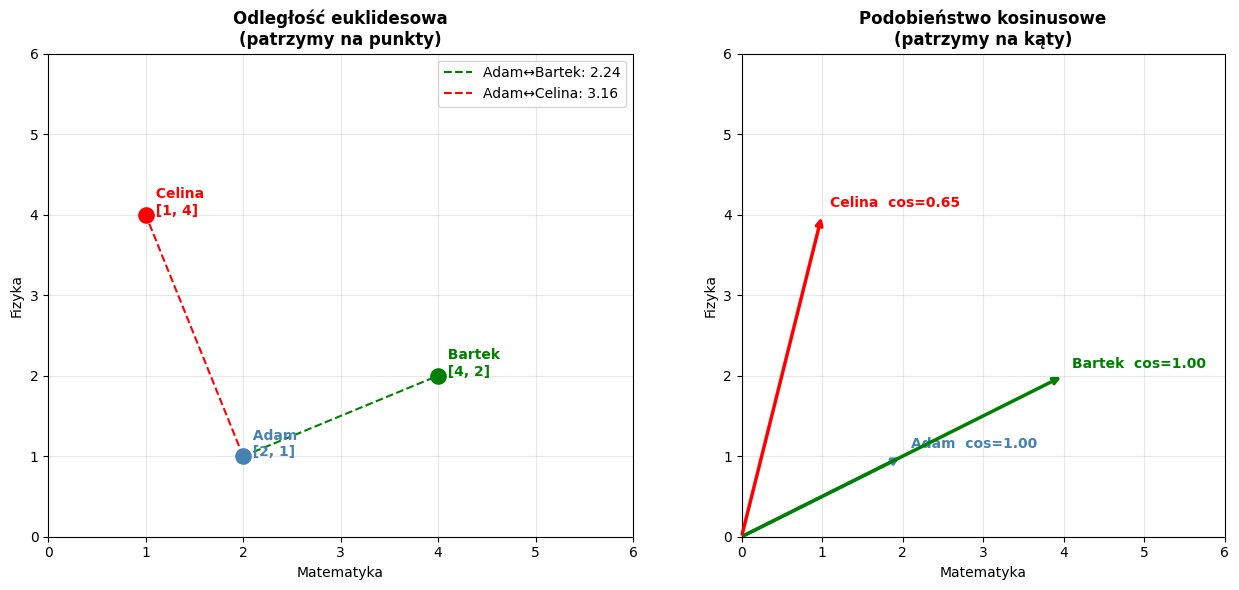

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

colors = {'Adam': 'steelblue', 'Bartek': 'green', 'Celina': 'red'}
points = {'Adam': adam, 'Bartek': bartek, 'Celina': celina}

# --- lewy wykres: odległość euklidesowa ---
ax = axes[0]
ax.set_title("Odległość euklidesowa\n(patrzymy na punkty)", fontsize=12, fontweight='bold')

for name, pt in points.items():
    ax.scatter(*pt, color=colors[name], s=120, zorder=5)
    ax.annotate(f"  {name}\n  [{pt[0]}, {pt[1]}]", pt, fontsize=10, color=colors[name], fontweight='bold')

# linie odległości od Adama
for name in ['Bartek', 'Celina']:
    pt = points[name]
    ax.plot([adam[0], pt[0]], [adam[1], pt[1]],
            '--', color=colors[name], lw=1.5,
            label=f"Adam↔{name}: {euclidean(adam, pt):.2f}")

ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.set_xlabel("Matematyka"); ax.set_ylabel("Fizyka")
ax.grid(True, alpha=0.3); ax.legend(fontsize=10)

# --- prawy wykres: podobieństwo kosinusowe ---
ax = axes[1]
ax.set_title("Podobieństwo kosinusowe\n(patrzymy na kąty)", fontsize=12, fontweight='bold')

for name, pt in points.items():
    ax.annotate("", xy=pt, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=colors[name], lw=2.5))
    ax.text(pt[0] + 0.1, pt[1] + 0.1, f"{name}  cos={cosine_sim(adam, pt):.2f}",
            fontsize=10, color=colors[name], fontweight='bold')

ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.set_xlabel("Matematyka"); ax.set_ylabel("Fizyka")
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## Podobieństwo kosinusowe — czym jest i po co je liczymy?

### Intuicja

Podobieństwo kosinusowe mierzy **kąt między dwoma wektorami**, a nie odległość między nimi.  
Nie obchodzi nas jak długie są wektory — tylko czy **wskazują w tym samym kierunku**.

W rozpoznawaniu twarzy każda twarz to wektor 512 liczb (embedding).  
Pytamy: *czy te dwa wektory-twarze wskazują w tym samym kierunku?*  
Jeśli tak → ta sama osoba.

---

### Wzór

$$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \cdot \|\vec{B}\|}$$

| Symbol | Co oznacza |
|---|---|
| $\vec{A} \cdot \vec{B}$ | iloczyn skalarny (suma iloczynów odpowiednich współrzędnych) |
| $\|\vec{A}\|$ | długość wektora A (pierwiastek z sumy kwadratów) |
| $\theta$ | kąt między wektorami |

Wynik mieści się w przedziale **−1 … 1**:

| Wartość | Interpretacja |
|---|---|
| **1.0** | wektory identyczne (ta sama twarz) |
| **0.0** | wektory prostopadłe (brak związku) |
| **−1.0** | wektory przeciwne |

W praktyce dla InsightFace: **> 0.5** → prawdopodobnie ta sama osoba, **< 0.3** → inna osoba.

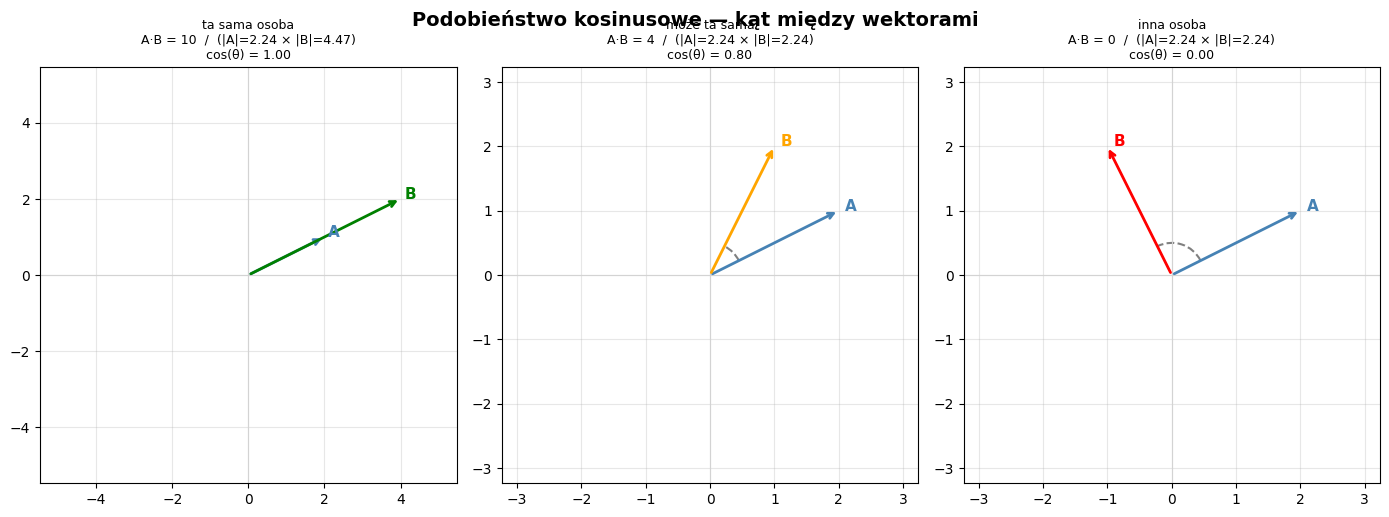

=== Krok po kroku (A=[2,1], B=[4,2]) ===
1. Iloczyn skalarny:  A·B = 2×4 + 1×2 = 10
2. Długość A:         |A| = √(2²+1²) = 2.2361
3. Długość B:         |B| = √(4²+2²) = 4.4721
4. cos(θ) = 10 / (2.2361 × 4.4721) = 1.0000

→ Wynik 1.0 bo B = 2×A — oba wektory wskazują dokładnie ten sam kierunek!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- trzy pary wektorów 2D jako przykład ---
pairs = [
    ("ta sama osoba",  np.array([2, 1]),   np.array([4, 2]),   "green"),
    ("może ta sama",   np.array([2, 1]),   np.array([1, 2]),   "orange"),
    ("inna osoba",     np.array([2, 1]),   np.array([-1, 2]),  "red"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Podobieństwo kosinusowe — kąt między wektorami", fontsize=14, fontweight='bold')

for ax, (label, A, B, color) in zip(axes, pairs):
    # liczymy podobieństwo
    sim = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

    # rysujemy wektory ze środka układu
    ax.annotate("", xy=A, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
    ax.annotate("", xy=B, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2))

    # łuk kąta
    theta1 = np.degrees(np.arctan2(A[1], A[0]))
    theta2 = np.degrees(np.arctan2(B[1], B[0]))
    arc = mpatches.Arc((0, 0), 1, 1, angle=0,
                       theta1=min(theta1, theta2), theta2=max(theta1, theta2),
                       color='gray', lw=1.5, linestyle='--')
    ax.add_patch(arc)

    # etykiety wektorów
    ax.text(A[0] + 0.1, A[1], "A", fontsize=11, color="steelblue", fontweight='bold')
    ax.text(B[0] + 0.1, B[1], "B", fontsize=11, color=color,      fontweight='bold')

    # wzór ręcznie dla 2D
    dot    = A[0]*B[0] + A[1]*B[1]
    norm_a = np.sqrt(A[0]**2 + A[1]**2)
    norm_b = np.sqrt(B[0]**2 + B[1]**2)

    ax.set_title(f"{label}\n"
                 f"A·B = {dot}  /  (|A|={norm_a:.2f} × |B|={norm_b:.2f})\n"
                 f"cos(θ) = {sim:.2f}", fontsize=9)

    lim = max(np.linalg.norm(A), np.linalg.norm(B)) + 1
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color='lightgray', lw=0.8)
    ax.axvline(0, color='lightgray', lw=0.8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- krok po kroku dla pierwszej pary ---
A, B = np.array([2, 1]), np.array([4, 2])
print("=== Krok po kroku (A=[2,1], B=[4,2]) ===")
print(f"1. Iloczyn skalarny:  A·B = 2×4 + 1×2 = {np.dot(A,B)}")
print(f"2. Długość A:         |A| = √(2²+1²) = {np.linalg.norm(A):.4f}")
print(f"3. Długość B:         |B| = √(4²+2²) = {np.linalg.norm(B):.4f}")
print(f"4. cos(θ) = {np.dot(A,B)} / ({np.linalg.norm(A):.4f} × {np.linalg.norm(B):.4f}) = {np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B)):.4f}")
print(f"\n→ Wynik 1.0 bo B = 2×A — oba wektory wskazują dokładnie ten sam kierunek!")

---
## Zastosowanie w NLP — porównywanie zdań

W NLP każde zdanie zamieniamy na wektor liczb (tzw. **bag of words**).  
Każda pozycja wektora to jedno słowo ze słownika — wartość to liczba wystąpień.

Przykład ze słownikiem 5 słów: `[pies, kot, gryzie, miauczy, śpi]`

| Zdanie | pies | kot | gryzie | miauczy | śpi |
|---|---|---|---|---|---|
| „pies gryzie kota" | 1 | 1 | 1 | 0 | 0 |
| „pies śpi" | 1 | 0 | 0 | 0 | 1 |
| „kot miauczy" | 0 | 1 | 0 | 1 | 0 |

**Pytanie:** które zdanie jest najbardziej podobne do „pies gryzie kota"?

In [4]:
import numpy as np

# słownik: [pies, kot, gryzie, miauczy, śpi]
s1 = np.array([1, 1, 1, 0, 0])  # "pies gryzie kota"
s2 = np.array([1, 0, 0, 0, 1])  # "pies śpi"
s3 = np.array([0, 1, 0, 1, 0])  # "kot miauczy"

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

print('Porównanie do: "pies gryzie kota"')
print()
print(f'  "pies spi"    - cosinus: {cosine_sim(s1, s2):.3f}  |  euklidesowo: {euclidean(s1, s2):.3f}')
print(f'  "kot miauczy" - cosinus: {cosine_sim(s1, s3):.3f}  |  euklidesowo: {euclidean(s1, s3):.3f}')
print()
print('Cosinus: "pies spi" jest blizsze -- oba zdania mowia o psie.')
print('Euklidesowo: tak samo daleko -- obie roznia sie o 2 slowa.')

Porównanie do: "pies gryzie kota"

  "pies spi"    - cosinus: 0.408  |  euklidesowo: 1.732
  "kot miauczy" - cosinus: 0.408  |  euklidesowo: 1.732

Cosinus: "pies spi" jest blizsze -- oba zdania mowia o psie.
Euklidesowo: tak samo daleko -- obie roznia sie o 2 slowa.


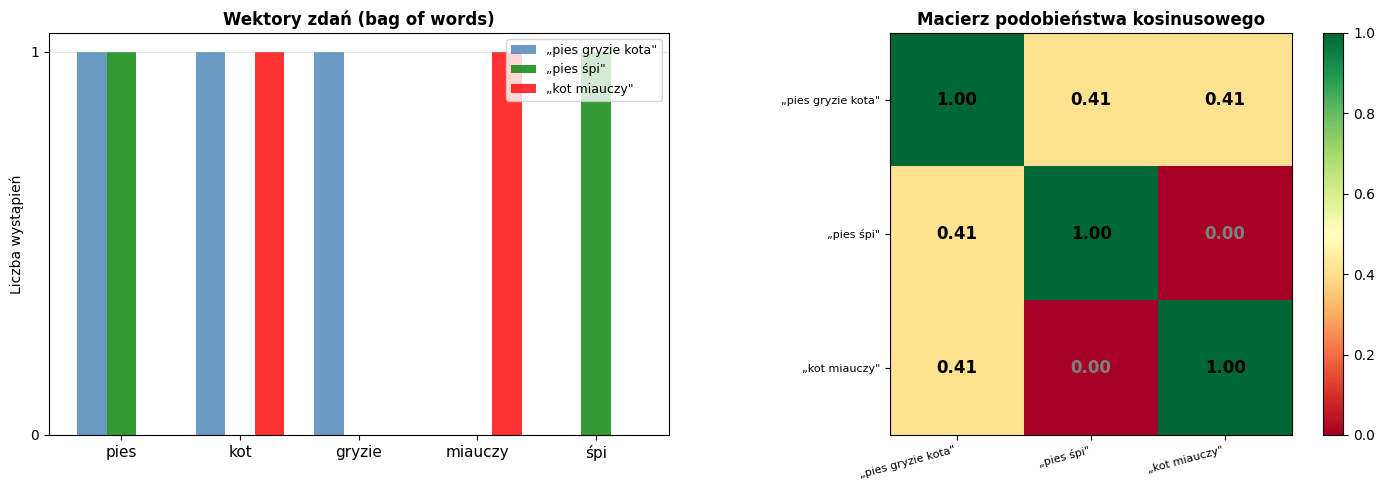

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

słowa = ['pies', 'kot', 'gryzie', 'miauczy', 'śpi']
zdania = {
    '„pies gryzie kota"': (s1, 'steelblue'),
    '„pies śpi"':         (s2, 'green'),
    '„kot miauczy"':      (s3, 'red'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- lewy: wektory jako słupki ---
ax = axes[0]
x = np.arange(len(słowa))
w = 0.25
for i, (label, (vec, color)) in enumerate(zdania.items()):
    ax.bar(x + i * w, vec, width=w, label=label, color=color, alpha=0.8)

ax.set_xticks(x + w)
ax.set_xticklabels(słowa, fontsize=11)
ax.set_yticks([0, 1])
ax.set_ylabel("Liczba wystąpień")
ax.set_title("Wektory zdań (bag of words)", fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- prawy: macierz podobieństw ---
ax = axes[1]
labels = list(zdania.keys())
n = len(labels)
matrix = np.zeros((n, n))
for i, (_, (vi, _)) in enumerate(zdania.items()):
    for j, (_, (vj, _)) in enumerate(zdania.items()):
        matrix[i, j] = cosine_sim(vi, vj)

im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, fontsize=8, rotation=15, ha='right')
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Macierz podobieństwa kosinusowego", fontweight='bold')

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='black' if matrix[i,j] > 0.3 else 'gray')

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()